# 외국어 문장 판별

In [ ]:
# 머신러닝을 활용하여 외국어 글자를 읽어 들이고 어느 나라 언어인지 판정하는 프로그램 작성

# 해당 글자가 어떤 언어인지 판정
# 알파벳의 출현횟수 확인
# 데이터를 그래프로 그리기
# 웹서비스 배포

# [사용 알고리즘]
#    SVM (Support Vector Machine)

## 외국어 판정
##### 알파벳을 사용한다고 다 '영어' 가 아니다..     어느나라 말인지 판정해보자는 것이다

## 판정 방법
글자를 --> 벡터로?

In [ ]:
# 글자 데이터를 벡터로 변경해서 사용해야 함  어떻게?

# '언어' 가 다르면 알파벳의 출현빈도가 다르다 <--- 언어학적으로 알려진 사실
# '언어' 마다 자주 사용하는 표현과 단어가 다르기 때문이다.

# 이를 활용하여 'a' 부터 'z' 까지의 출현 빈도(벡터화!)를 확인하고 이를 특징으로 사용

# import

In [1]:
from sklearn import svm, metrics
import joblib
import glob, os.path, re, json

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import Image

In [2]:
# colab 한글 fonts-nanum 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,862 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

In [3]:
# 다운로드한 한글 폰트를 matplotlib 에 세팅
import matplotlib.font_manager as fm

NanumBarunGothic_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 리눅스 폰트 경로
fm.fontManager.addfont(NanumBarunGothic_path) # 폰트메니저에 폰트를 직접적으로 주입

plt.rc('font', family='NanumBarunGothic')

# 샘플데이터 다운로드

In [4]:
# lang.zip 파일
url = "https://www.dropbox.com/scl/fi/y7isf44robkebkydm50vu/lang.zip?rlkey=69xe9g8iqf8r4fkohpneyw5on&st=63zhpu4i&dl=1"

In [6]:
# 다운로드후 압축 풀기
import requests

response = requests.get(url)

with open("lang.zip", "wb") as f:
  f.write(response.content)


In [7]:
import zipfile

# 현재경로에 압축 해제
with zipfile.ZipFile("lang.zip", "r") as z:
  z.extractall(".")

In [ ]:
# 언어별 풍부한 데이터가 있는 위키피디아 글자 사용.

# lang/lang.zip 파일을 풀고 lang 폴더에 보면 샘플데이터 있슴

# lang
#   ├ test     테스트데이터 8개
#   └ train    학습데이터 20개        <-- 양이 부족하긴 하지만.  작게 테스트 할 용도

#  en 영어
#  fr 프랑스어
#  id 인도네시아어
#  tl  타갈로그어   <-- 필리핀에서 많이 사용하는 언어



# 텍스트를 읽어 들이고 출현빈도 조사 하기

In [8]:
fname = "./lang/train/en-1.txt"

In [10]:
name = os.path.basename(fname)
lang = re.match(r'^[a-z]{2,}', name).group()  # 파일 앞 2글 추출

name, lang

('en-1.txt', 'en')

In [11]:
with open(fname, "r", encoding='utf-8') as f:
  text = f.read().lower()

text[:200]

'\n\n\n\nthe main henry ford museum building houses some of the classrooms for the henry ford academy\n\n\nhenry ford academy is the first charter school in the united states to be developed jointly by a glob'

In [13]:
# 알파벳 개수 세기

cnt = []

for i in range(26):
  ch = chr(i + ord('a'))
  cnt.append(text.count(ch))

print(cnt)


[349, 59, 210, 212, 484, 72, 88, 201, 340, 8, 25, 247, 121, 356, 412, 76, 0, 357, 282, 370, 119, 45, 65, 3, 92, 2]


In [15]:
# 전처리 (정규화)
total = sum(cnt)
freq = list(map(lambda n: n / total, cnt))

print(freq)

[0.07595212187159957, 0.012840043525571273, 0.04570184983677911, 0.04613710554951034, 0.10533188248095757, 0.015669205658324265, 0.019151251360174103, 0.043743199129488576, 0.07399347116430903, 0.0017410228509249185, 0.00544069640914037, 0.05375408052230685, 0.026332970620239392, 0.07747551686615888, 0.08966267682263329, 0.016539717083786723, 0.0, 0.07769314472252448, 0.061371055495103376, 0.08052230685527748, 0.02589771490750816, 0.009793253536452665, 0.014145810663764961, 0.0006528835690968443, 0.02002176278563656, 0.0004352557127312296]


In [16]:
freq, lang   # data, target(label)

([0.07595212187159957,
  0.012840043525571273,
  0.04570184983677911,
  0.04613710554951034,
  0.10533188248095757,
  0.015669205658324265,
  0.019151251360174103,
  0.043743199129488576,
  0.07399347116430903,
  0.0017410228509249185,
  0.00544069640914037,
  0.05375408052230685,
  0.026332970620239392,
  0.07747551686615888,
  0.08966267682263329,
  0.016539717083786723,
  0.0,
  0.07769314472252448,
  0.061371055495103376,
  0.08052230685527748,
  0.02589771490750816,
  0.009793253536452665,
  0.014145810663764961,
  0.0006528835690968443,
  0.02002176278563656,
  0.0004352557127312296],
 'en')

## check_freq(fname) 함수

In [20]:
def check_freq(fname):  # -> Tuple[List, str]
    name = os.path.basename(fname)   # 파일 이름
    lang = re.match(r'^[a-z]{2,}', name).group()  # 파일 앞 2글자 추출  (문자열 slicing으로 해도 될텐데?)
    with open(fname, "r", encoding='utf-8') as f:
        text = f.read().lower()

    # 알파벳 출현빈도
    cnt = []
    for i in range(26):
        ch = chr(i + ord('a'))
        cnt.append(text.count(ch))

    # 정규화 하기.. normalizing.
    # 각 알파벳의 출현 빈도를 확률로 재계산
    total = sum(cnt)
    freq = list(map(lambda n: n / total, cnt))
    return (freq, lang)

# 테스트
check_freq(fname)

([0.07595212187159957,
  0.012840043525571273,
  0.04570184983677911,
  0.04613710554951034,
  0.10533188248095757,
  0.015669205658324265,
  0.019151251360174103,
  0.043743199129488576,
  0.07399347116430903,
  0.0017410228509249185,
  0.00544069640914037,
  0.05375408052230685,
  0.026332970620239392,
  0.07747551686615888,
  0.08966267682263329,
  0.016539717083786723,
  0.0,
  0.07769314472252448,
  0.061371055495103376,
  0.08052230685527748,
  0.02589771490750816,
  0.009793253536452665,
  0.014145810663764961,
  0.0006528835690968443,
  0.02002176278563656,
  0.0004352557127312296],
 'en')

## load_files(path) 파일(들) 처리 함수
학습용(train), 테스트용(test) 폴더 안의 파일들을 일괄 벡터화

In [ ]:
# load_files(파일데이터 있는 경로)


# 호출 예시
# data = load_files("./lang/train/*.txt")
# test = load_files("./lang/test/*.txt")


# 결과 (리턴값)  dict
# {
#    freqs :  [
#                     [0.034, 0.34, . ...  , 0.034],       <-- 알파벳의 빈도수
#                     [0.034, 0.34, . ...  , 0.034],
#                      ..
#                 ]
#    labels : ['en', 'en', 'fr', 'fr', 'id', 'id', 'tl', 'tl']
# }

In [24]:
def load_files(path):
  freqs = []    # 출현빈도
  labels = []   # 레이블

  file_list = glob.glob(path)
  for fname in file_list:
    # print(fname)
    freq, label = check_freq(fname)

    freqs.append(freq)
    labels.append(label)

  return {
      "freqs": freqs,
      "labels": labels,
  }

data = load_files(r"./lang/train/*.txt")
test = load_files(r"./lang/test/*.txt")

len(data['freqs']), len(test['freqs'])

(20, 8)

# JSON 저장

In [25]:
# 시각화를 위해 JSON 으로 결과 저장하기

with open(r'./lang/freq.json', 'w', encoding='utf-8') as fp:
  json.dump([data, test], fp)   # [0] 번째가 train, [1] 번째가 test


In [26]:
# 저장된 모양새 확인해보자
!cat ./lang/freq.json


[{"freqs": [[0.07164591977869986, 0.012171507607192255, 0.04564315352697095, 0.0326417704011065, 0.12005532503457815, 0.014661134163208852, 0.02517289073305671, 0.02351313969571231, 0.0946058091286307, 0.0024896265560165973, 0.0016597510373443983, 0.05698478561549101, 0.022406639004149378, 0.07551867219917012, 0.07662517289073306, 0.02074688796680498, 0.0016597510373443983, 0.05394190871369295, 0.08796680497925312, 0.08105117565698479, 0.029045643153526972, 0.018810511756569847, 0.01189488243430152, 0.0005532503457814661, 0.017980636237897647, 0.0005532503457814661], [0.07380639509417433, 0.020367936925098553, 0.031099430573806396, 0.039640823477879984, 0.14126149802890933, 0.020367936925098553, 0.020367936925098553, 0.05694261936049058, 0.06504599211563732, 0.0032851511169513796, 0.005913272010512484, 0.039640823477879984, 0.02890932982917214, 0.06219886114761279, 0.06614104248795445, 0.018834866403854577, 0.0004380201489268506, 0.07249233464739378, 0.059570740254051686, 0.09548839246

# 학습하기

In [ ]:
# train 용 : data 쪽도, label 도 준비되었어요
# test 용 : data 쪽도, label 도 준비되었어요

#  SVC() 로 학습 (Support Vector Classifier, 분류모델 알고리즘)

In [29]:
# 모델 생성 & 학습
clf = svm.SVC()
clf.fit(data['freqs'], data['labels'])

SVC()

In [30]:
# 평가
clf.score(test['freqs'], test['labels'])

1.0

# 예측하기

In [ ]:
# test 세트로 예측하기

In [32]:
# test 세트로 예측하기
predict = clf.predict(test['freqs'])
print('예측', predict)
print('정답', test['labels'])


예측 ['id' 'fr' 'en' 'id' 'tl' 'fr' 'tl' 'en']
정답 ['id', 'fr', 'en', 'id', 'tl', 'fr', 'tl', 'en']


In [33]:
ac_score = metrics.accuracy_score(test['labels'], predict)

print('정답률 =', ac_score)

정답률 = 1.0


In [55]:
cl_report = metrics.classification_report(test['labels'], predict)

print(cl_report)

              precision    recall  f1-score   support

          en       1.00      1.00      1.00         2
          fr       1.00      1.00      1.00         2
          id       1.00      1.00      1.00         2
          tl       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



# 데이터 분포 시각화

In [ ]:
# 언어별로 알파벳 빈도가 다르다..   그럼 어느 정도로 알파벳 빈도가 다른지 시각적으로 확인

In [34]:
# 알파벳 출현빈도 데이터 읽어 들이기
# 직전의 json 파일로부터

with open(r'./lang/freq.json', "r", encoding="utf-8") as fp:
  freq = json.load(fp)  # loads() 가 아니라 load(파일)

freq  # list   <- 0번째가 train, 1번째 test

[{'freqs': [[0.07164591977869986,
    0.012171507607192255,
    0.04564315352697095,
    0.0326417704011065,
    0.12005532503457815,
    0.014661134163208852,
    0.02517289073305671,
    0.02351313969571231,
    0.0946058091286307,
    0.0024896265560165973,
    0.0016597510373443983,
    0.05698478561549101,
    0.022406639004149378,
    0.07551867219917012,
    0.07662517289073306,
    0.02074688796680498,
    0.0016597510373443983,
    0.05394190871369295,
    0.08796680497925312,
    0.08105117565698479,
    0.029045643153526972,
    0.018810511756569847,
    0.01189488243430152,
    0.0005532503457814661,
    0.017980636237897647,
    0.0005532503457814661],
   [0.07380639509417433,
    0.020367936925098553,
    0.031099430573806396,
    0.039640823477879984,
    0.14126149802890933,
    0.020367936925098553,
    0.020367936925098553,
    0.05694261936049058,
    0.06504599211563732,
    0.0032851511169513796,
    0.005913272010512484,
    0.039640823477879984,
    0.02890932982

In [35]:
freq[0] # data

{'freqs': [[0.07164591977869986,
   0.012171507607192255,
   0.04564315352697095,
   0.0326417704011065,
   0.12005532503457815,
   0.014661134163208852,
   0.02517289073305671,
   0.02351313969571231,
   0.0946058091286307,
   0.0024896265560165973,
   0.0016597510373443983,
   0.05698478561549101,
   0.022406639004149378,
   0.07551867219917012,
   0.07662517289073306,
   0.02074688796680498,
   0.0016597510373443983,
   0.05394190871369295,
   0.08796680497925312,
   0.08105117565698479,
   0.029045643153526972,
   0.018810511756569847,
   0.01189488243430152,
   0.0005532503457814661,
   0.017980636237897647,
   0.0005532503457814661],
  [0.07380639509417433,
   0.020367936925098553,
   0.031099430573806396,
   0.039640823477879984,
   0.14126149802890933,
   0.020367936925098553,
   0.020367936925098553,
   0.05694261936049058,
   0.06504599211563732,
   0.0032851511169513796,
   0.005913272010512484,
   0.039640823477879984,
   0.02890932982917214,
   0.06219886114761279,
   0.06

In [36]:
freq[1]  # test

{'freqs': [[0.16473616473616473,
   0.026052026052026053,
   0.014586014586014585,
   0.04157404157404158,
   0.08825708825708825,
   0.006201006201006201,
   0.035997035997036,
   0.025116025116025117,
   0.08205608205608206,
   0.007254007254007254,
   0.03853203853203853,
   0.04301704301704302,
   0.040872040872040875,
   0.08985608985608985,
   0.03116103116103116,
   0.03634803634803635,
   0.000156000156000156,
   0.053625053625053626,
   0.048789048789048786,
   0.05323505323505324,
   0.047424047424047426,
   0.00468000468000468,
   0.004602004602004602,
   0.000468000468000468,
   0.01482001482001482,
   0.000585000585000585],
  [0.07187479305092603,
   0.011412551599302444,
   0.03847597183285137,
   0.04033023553563939,
   0.13935674709167567,
   0.012185161475464118,
   0.015385973819562483,
   0.018410189620538177,
   0.0794905189730911,
   0.004150018763382707,
   0.002384053332156023,
   0.05874042515617757,
   0.033200150107061656,
   0.07083728836008035,
   0.06988808

## 언어마다 계산하기
- **확률의 평균?**
- 동일한 길이의 표본들에서의 단순평균

In [ ]:
# 예를 들면
# 첫번째 텍스트에서 'b' 가 나온 확률 0.2
# 두번째 텍스트에서 'b' 가 나온 확률 0.6

# 결국 'b' 가 나온확률은  일까?
# ( 0.2 + 0.6 ) / 2      <- (단 a~z 까지 26개로 길이가 동일한 경우.  아니라면 가중치를 두어야 한다)

In [40]:
for i, lbl in enumerate(freq[0]['labels']):
  print(i, lbl)
  print(freq[0]['freqs'][i])

0 en
[0.07164591977869986, 0.012171507607192255, 0.04564315352697095, 0.0326417704011065, 0.12005532503457815, 0.014661134163208852, 0.02517289073305671, 0.02351313969571231, 0.0946058091286307, 0.0024896265560165973, 0.0016597510373443983, 0.05698478561549101, 0.022406639004149378, 0.07551867219917012, 0.07662517289073306, 0.02074688796680498, 0.0016597510373443983, 0.05394190871369295, 0.08796680497925312, 0.08105117565698479, 0.029045643153526972, 0.018810511756569847, 0.01189488243430152, 0.0005532503457814661, 0.017980636237897647, 0.0005532503457814661]
1 en
[0.07380639509417433, 0.020367936925098553, 0.031099430573806396, 0.039640823477879984, 0.14126149802890933, 0.020367936925098553, 0.020367936925098553, 0.05694261936049058, 0.06504599211563732, 0.0032851511169513796, 0.005913272010512484, 0.039640823477879984, 0.02890932982917214, 0.06219886114761279, 0.06614104248795445, 0.018834866403854577, 0.0004380201489268506, 0.07249233464739378, 0.059570740254051686, 0.09548839246605

In [ ]:
# 아래 결과 만들어 보자..  언어별 빈도수

# {
# 'en': [0.0739194768069211,  0.020681128178765107, ...  0.0008863430770681183],
# ‘fr’': [0.0739194768069211,  0.020681128178765107, ...  0.0008863430770681183],
# …
# }


In [41]:
# 아까 직전에 json 저장시
# json.dump([data, test], fp)  <--  리스트인데 0번째는 data, 1번째는 test 였다..
lang_dic = {}

for i, lbl in enumerate(freq[0]['labels']):
  fq = freq[0]['freqs'][i]

  # 기존에 lbl 키값이 없었으면 추가
  if lbl not in lang_dic:
    lang_dic[lbl] = fq
    continue

  # 있었다면 lbl 에 누적.  등장확률 계속 더하고 나누기 2
  for idx, v in enumerate(fq):
    lang_dic[lbl][idx] = (lang_dic[lbl][idx] + v) / 2


lang_dic

{'en': [0.07919395396411505,
  0.01866397678685317,
  0.03517114439694648,
  0.04043587316020367,
  0.12629422985406755,
  0.01690803854642587,
  0.026199415456301306,
  0.037052489692433924,
  0.07430818641226375,
  0.0022962698653837352,
  0.008348137208933425,
  0.046250300792952934,
  0.024579205006961112,
  0.06207321565745061,
  0.07669574190261029,
  0.018840994847773955,
  0.002920584272137293,
  0.07979525261029731,
  0.06956072937066991,
  0.0817468372072504,
  0.028211717206303152,
  0.011786849275849168,
  0.0151979498242219,
  0.002157053899395843,
  0.014617211883578238,
  0.000694640898619952],
 'id': [0.15941506979276654,
  0.02528715121313381,
  0.008536672974494645,
  0.040262183045979526,
  0.08843602850331718,
  0.009184132056867413,
  0.03823132680303532,
  0.018612379696549948,
  0.09584255510427034,
  0.00649823279867363,
  0.03699020431689139,
  0.0379983473782575,
  0.037500793690282336,
  0.09068041941745106,
  0.036291527095638265,
  0.031987311872335,
  4.46

## dataframe 준비
그래프 만들기 위해

In [42]:
asclist = [chr(n) for n in range(97, 97 + 26)]
print(asclist)  # 학인

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [43]:
df = pd.DataFrame(lang_dic, index = asclist)
df  # 확인

,en,id,tl,fr
a,0.079194,0.159415,0.209902,0.076801
b,0.018664,0.025287,0.022493,0.012353
c,0.035171,0.008537,0.013781,0.037444
d,0.040436,0.040262,0.025730,0.051519
e,0.126294,0.088436,0.046955,0.151211
f,0.016908,0.009184,0.004321,0.014274
g,0.026199,0.038231,0.061743,0.012625
h,0.037052,0.018612,0.012079,0.015303
i,0.074308,0.095843,0.079238,0.076292
j,0.002296,0.006498,0.001809,0.003049


## 그래프 그리기

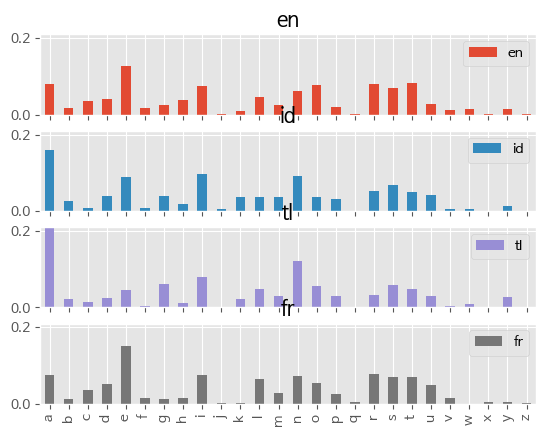

In [48]:
plt.style.use('ggplot')
df.plot(kind='bar', subplots=True, ylim=(0, 0.21))

plt.show()

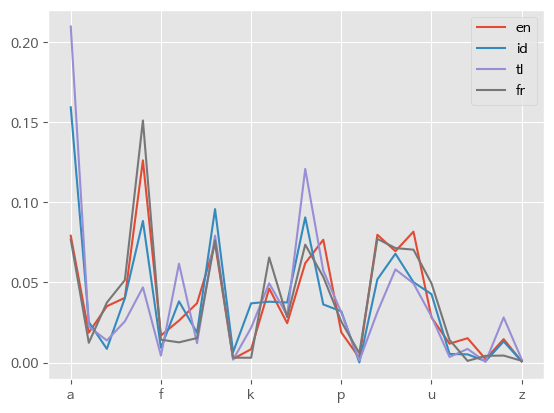

In [49]:
# kind 변경하면 다른 형태의 그래프 작성 가능
plt.style.use('ggplot')
df.plot(kind='line')
plt.show()


# 판정함수

In [50]:
def detect_lang(text):
  # 알파벳 출현빈도 구하기
  text = text.lower()

  cnt = []
  for i in range(26):
      ch = chr(i + ord('a'))
      cnt.append(text.count(ch))

  total = sum(cnt)
  if total == 0: return "입력이 없습니다"

  # 입력데이터 준비 (전처리)
  freq = list(map(lambda n: n / total, cnt))

  # 예측 predict
  pred = clf.predict([freq])

  # 리턴할 문자열
  lang_dic = {
      "en": "영어",
      "fr": "프랑스어",
      "id": "인도네시아어",
      "tl": "타갈로그어"
  }

  return lang_dic[pred[0]]



In [ ]:
# 창세기 1장
# 영어 https://www.wordproject.org/bibles/drc/01/1.htm
# 프랑스어 https://www.wordproject.org/bibles/fr/01/1.htm
# 인도네시아어 https://www.wordproject.org/bibles/id_tb/01/1.htm
# 타갈로그어 https://www.wordproject.org/bibles/tl/01/1.htm


In [51]:
# 동작확인
scripts = [
    # 영어  https://www.wordproject.org/bibles/drc/01/1.htm
    """
    In the beginning God created heaven, and earth.2 And the earth was void and empty, and darkness was upon the face of the deep; and the spirit of God moved over the waters.3 And God said: Be light made. And light was made.4 And God saw the light that it was good; and he divided the light from the darkness.5 And he called the light Day, and the darkness Night; and there was evening and morning one day.6 And God said: Let there be a firmament made amidst the waters: and let it divide the waters from the waters.7 And God made a firmament, and divided the waters that were under the firmament, from those that were above the firmament, and it was so.8 And God called the firmament, Heaven; and the evening and morning were the second day.9 God also said: Let the waters that are under the heaven, be gathered together into one place: and let the dry land appear. And it was so done.10 And God called the dry land, Earth; and the gathering together of the waters, he called Seas. And God saw that it was good.11 And he said: Let the earth bring forth the green herb, and such as may seed, and the fruit tree yielding fruit after its kind, which may have seed in itself upon the earth. And it was so done.12 And the earth brought forth the green herb, and such as yieldeth seed according to its kind, and the tree that beareth fruit having seed each one according to its kind. And God saw that it was good.13 And the evening and the morning were the third day.14 And God said: Let there be lights made in the firmament of heaven, to divide the day and the night, and let them be for signs, and for seasons, and for days and years:15 To shine in the firmament of heaven, and to give light upon the earth. And it was so done.16 And God made two great lights: a greater light to rule the day; and a lesser light to rule the night: and the stars.17 And he set them in the firmament of heaven to shine upon the earth.18 And to rule the day and the night, and to divide the light and the darkness. And God saw that it was good.19 And the evening and morning were the fourth day.20 God also said: Let the waters bring forth the creeping creature having life, and the fowl that may fly over the earth under the firmament of heaven.21 And God created the great whales, and every living and moving creature, which the waters brought forth, according to their kinds, and every winged fowl according to its kind. And God saw that it was good.22 And he blessed them, saying: Increase and multiply, and fill the waters of the sea: and let the birds be multiplied upon the earth.23 And the evening and morning were the fifth day.24 And God said: Let the earth bring forth the living creature in its kind, cattle and creeping things, and beasts of the earth, according to their kinds. And it was so done.25 And God made the beasts of the earth according to their kinds, and cattle, and every thing that creepeth on the earth after its kind. And God saw that it was good.26 And he said: Let us make man to our image and likeness: and let him have dominion over the fishes of the sea, and the fowls of the air, and the beasts, and the whole earth, and every creeping creature that moveth upon the earth.27 And God created man to his own image: to the image of God he created him: male and female he created them.28 And God blessed them, saying: Increase and multiply, and fill the earth, and subdue it, and rule over the fishes of the sea, and the fowls of the air, and all living creatures that move upon the earth.29 And God said: Behold I have given you every herb bearing seed upon the earth, and all trees that have in themselves seed of their own kind, to be your meat:30 And to all the beasts of the earth, and to every fowl of the air, and to all that move upon the earth, and wherein there is life, that they may have to feed upon. And it was so done.31 And God saw all the things that he had made, and they were very good. And the evening and morning were the sixth day.
    """,

    # 인도네시아어  https://www.wordproject.org/bibles/fr/01/1.htm
    """
    Pada mulanya Allah menciptakan langit dan bumi.2 Bumi belum berbentuk dan kosong; gelap gulita menutupi samudera raya, dan Roh Allah melayang-layang di atas permukaan air.3 Berfirmanlah Allah: "Jadilah terang." Lalu terang itu jadi.4 Allah melihat bahwa terang itu baik, lalu dipisahkan-Nyalah terang itu dari gelap.5 Dan Allah menamai terang itu siang, dan gelap itu malam. Jadilah petang dan jadilah pagi, itulah hari pertama.6 Berfirmanlah Allah: "Jadilah cakrawala di tengah segala air untuk memisahkan air dari air."7 Maka Allah menjadikan cakrawala dan Ia memisahkan air yang ada di bawah cakrawala itu dari air yang ada di atasnya. Dan jadilah demikian.8 Lalu Allah menamai cakrawala itu langit. Jadilah petang dan jadilah pagi, itulah hari kedua.9 Berfirmanlah Allah: "Hendaklah segala air yang di bawah langit berkumpul pada satu tempat, sehingga kelihatan yang kering." Dan jadilah demikian.10 Lalu Allah menamai yang kering itu darat, dan kumpulan air itu dinamai-Nya laut. Allah melihat bahwa semuanya itu baik.11 Berfirmanlah Allah: "Hendaklah tanah menumbuhkan tunas-tunas muda, tumbuh-tumbuhan yang berbiji, segala jenis pohon buah-buahan yang menghasilkan buah yang berbiji, supaya ada tumbuh-tumbuhan di bumi." Dan jadilah demikian.12 Tanah itu menumbuhkan tunas-tunas muda, segala jenis tumbuh-tumbuhan yang berbiji dan segala jenis pohon-pohonan yang menghasilkan buah yang berbiji. Allah melihat bahwa semuanya itu baik.13 Jadilah petang dan jadilah pagi, itulah hari ketiga.14 Berfirmanlah Allah: "Jadilah benda-benda penerang pada cakrawala untuk memisahkan siang dari malam. Biarlah benda-benda penerang itu menjadi tanda yang menunjukkan masa-masa yang tetap dan hari-hari dan tahun-tahun,15 dan sebagai penerang pada cakrawala biarlah benda-benda itu menerangi bumi." Dan jadilah demikian.16 Maka Allah menjadikan kedua benda penerang yang besar itu, yakni yang lebih besar untuk menguasai siang dan yang lebih kecil untuk menguasai malam, dan menjadikan juga bintang-bintang.17 Allah menaruh semuanya itu di cakrawala untuk menerangi bumi,18 dan untuk menguasai siang dan malam, dan untuk memisahkan terang dari gelap. Allah melihat bahwa semuanya itu baik.19 Jadilah petang dan jadilah pagi, itulah hari keempat.20 Berfirmanlah Allah: "Hendaklah dalam air berkeriapan makhluk yang hidup, dan hendaklah burung beterbangan di atas bumi melintasi cakrawala."21 Maka Allah menciptakan binatang-binatang laut yang besar dan segala jenis makhluk hidup yang bergerak, yang berkeriapan dalam air, dan segala jenis burung yang bersayap. Allah melihat bahwa semuanya itu baik.22 Lalu Allah memberkati semuanya itu, firman-Nya: "Berkembangbiaklah dan bertambah banyaklah serta penuhilah air dalam laut, dan hendaklah burung-burung di bumi bertambah banyak."23 Jadilah petang dan jadilah pagi, itulah hari kelima.24 Berfirmanlah Allah: "Hendaklah bumi mengeluarkan segala jenis makhluk yang hidup, ternak dan binatang melata dan segala jenis binatang liar." Dan jadilah demikian.25 Allah menjadikan segala jenis binatang liar dan segala jenis ternak dan segala jenis binatang melata di muka bumi. Allah melihat bahwa semuanya itu baik.26 Berfirmanlah Allah: "Baiklah Kita menjadikan manusia menurut gambar dan rupa Kita, supaya mereka berkuasa atas ikan-ikan di laut dan burung-burung di udara dan atas ternak dan atas seluruh bumi dan atas segala binatang melata yang merayap di bumi."27 Maka Allah menciptakan manusia itu menurut gambar-Nya, menurut gambar Allah diciptakan-Nya dia; laki-laki dan perempuan diciptakan-Nya mereka.28 Allah memberkati mereka, lalu Allah berfirman kepada mereka: "Beranakcuculah dan bertambah banyak; penuhilah bumi dan taklukkanlah itu, berkuasalah atas ikan-ikan di laut dan burung-burung di udara dan atas segala binatang yang merayap di bumi."29 Berfirmanlah Allah: "Lihatlah, Aku memberikan kepadamu segala tumbuh-tumbuhan yang berbiji di seluruh bumi dan segala pohon-pohonan yang buahnya berbiji; itulah akan menjadi makananmu.30 Tetapi kepada segala binatang di bumi dan segala burung di udara dan segala yang merayap di bumi, yang bernyawa, Kuberikan segala tumbuh-tumbuhan hijau menjadi makanannya." Dan jadilah demikian.31 Maka Allah melihat segala yang dijadikan-Nya itu, sungguh amat baik. Jadilah petang dan jadilah pagi, itulah hari keenam.
    """,

    # 프랑스어  https://www.wordproject.org/bibles/id_tb/01/1.htm
    """
    Au commencement, Dieu créa les cieux et la terre.2 La terre était informe et vide: il y avait des ténèbres à la surface de l'abîme, et l'esprit de Dieu se mouvait au-dessus des eaux.3 Dieu dit: Que la lumière soit! Et la lumière fut.4 Dieu vit que la lumière était bonne; et Dieu sépara la lumière d'avec les ténèbres.5 Dieu appela la lumière jour, et il appela les ténèbres nuit. Ainsi, il y eut un soir, et il y eut un matin: ce fut le premier jour.6 Dieu dit: Qu'il y ait une étendue entre les eaux, et qu'elle sépare les eaux d'avec les eaux.7 Et Dieu fit l'étendue, et il sépara les eaux qui sont au-dessous de l'étendue d'avec les eaux qui sont au-dessus de l'étendue. Et cela fut ainsi.8 Dieu appela l'étendue ciel. Ainsi, il y eut un soir, et il y eut un matin: ce fut le second jour.9 Dieu dit: Que les eaux qui sont au-dessous du ciel se rassemblent en un seul lieu, et que le sec paraisse. Et cela fut ainsi.10 Dieu appela le sec terre, et il appela l'amas des eaux mers. Dieu vit que cela était bon.11 Puis Dieu dit: Que la terre produise de la verdure, de l'herbe portant de la semence, des arbres fruitiers donnant du fruit selon leur espèce et ayant en eux leur semence sur la terre. Et cela fut ainsi.12 La terre produisit de la verdure, de l'herbe portant de la semence selon son espèce, et des arbres donnant du fruit et ayant en eux leur semence selon leur espèce. Dieu vit que cela était bon.13 Ainsi, il y eut un soir, et il y eut un matin: ce fut le troisième jour.14 Dieu dit: Qu'il y ait des luminaires dans l'étendue du ciel, pour séparer le jour d'avec la nuit; que ce soient des signes pour marquer les époques, les jours et les années;15 et qu'ils servent de luminaires dans l'étendue du ciel, pour éclairer la terre. Et cela fut ainsi.16 Dieu fit les deux grands luminaires, le plus grand luminaire pour présider au jour, et le plus petit luminaire pour présider à la nuit; il fit aussi les étoiles.17 Dieu les plaça dans l'étendue du ciel, pour éclairer la terre,18 pour présider au jour et à la nuit, et pour séparer la lumière d'avec les ténèbres. Dieu vit que cela était bon.19 Ainsi, il y eut un soir, et il y eut un matin: ce fut le quatrième jour.20 Dieu dit: Que les eaux produisent en abondance des animaux vivants, et que des oiseaux volent sur la terre vers l'étendue du ciel.21 Dieu créa les grands poissons et tous les animaux vivants qui se meuvent, et que les eaux produisirent en abondance selon leur espèce; il créa aussi tout oiseau ailé selon son espèce. Dieu vit que cela était bon.22 Dieu les bénit, en disant: Soyez féconds, multipliez, et remplissez les eaux des mers; et que les oiseaux multiplient sur la terre.23 Ainsi, il y eut un soir, et il y eut un matin: ce fut le cinquième jour.24 Dieu dit: Que la terre produise des animaux vivants selon leur espèce, du bétail, des reptiles et des animaux terrestres, selon leur espèce. Et cela fut ainsi.25 Dieu fit les animaux de la terre selon leur espèce, le bétail selon son espèce, et tous les reptiles de la terre selon leur espèce. Dieu vit que cela était bon.26 Puis Dieu dit: Faisons l'homme à notre image, selon notre ressemblance, et qu'il domine sur les poissons de la mer, sur les oiseaux du ciel, sur le bétail, sur toute la terre, et sur tous les reptiles qui rampent sur la terre.27 Dieu créa l'homme à son image, il le créa à l'image de Dieu, il créa l'homme et la femme.28 Dieu les bénit, et Dieu leur dit: Soyez féconds, multipliez, remplissez la terre, et l'assujettissez; et dominez sur les poissons de la mer, sur les oiseaux du ciel, et sur tout animal qui se meut sur la terre.29 Et Dieu dit: Voici, je vous donne toute herbe portant de la semence et qui est à la surface de toute la terre, et tout arbre ayant en lui du fruit d'arbre et portant de la semence: ce sera votre nourriture.30 Et à tout animal de la terre, à tout oiseau du ciel, et à tout ce qui se meut sur la terre, ayant en soi un souffle de vie, je donne toute herbe verte pour nourriture. Et cela fut ainsi.31 Dieu vit tout ce qu'il avait fait et voici, cela était très bon. Ainsi, il y eut un soir, et il y eut un matin: ce fut le sixième jour.
    """,

    # 타갈로그어 (필리핀) https://www.wordproject.org/bibles/tl/01/1.htm
    """
    Nang pasimula ay nilikha ng Dios ang langit at ang lupa.2 At ang lupa ay walang anyo at walang laman; at ang kadiliman ay sumasa ibabaw ng kalaliman; at ang Espiritu ng Dios ay sumasa ibabaw ng tubig.3 At sinabi ng Dios Magkaroon ng liwanag; at nagkaroon ng liwanag.4 At nakita ng Dios ang liwanag na mabuti, at inihiwalay ng Dios ang liwanag sa kadiliman.5 At tinawag ng Dios ang liwanag na Araw, at tinawag niya ang kadiliman na Gabi. At nagkahapon at nagkaumaga ang unang araw.6 At sinabi ng Dios, Magkaroon ng isang kalawakan sa gitna ng tubig, at mahiwalay ang tubig sa kapuwa tubig.7 At ginawa ng Dios ang kalawakan, at inihiwalay ang tubig na nasa ilalim ng kalawakan, sa tubig na nasa itaas ng kalawakan: at nagkagayon.8 At tinawag ng Dios ang kalawakan na Langit. At nagkahapon at nagkaumaga ang ikalawang araw.9 At sinabi ng Dios, Mapisan ang tubig na nasa silong ng langit sa isang dako, at lumitaw ang katuyuan, at nagkagayon.10 At tinawag ng Dios ang katuyuan na Lupa, at ang kapisanan ng tubig ay tinawag niyang mga Dagat: at nakita ng Dios na mabuti.11 At sinabi ng Dios, Sibulan ang lupa ng damo, pananim na nagkakabinhi, at punong kahoy na namumunga ayon sa kaniyang pagkakahoy, na taglay ang kaniyang binhi sa ibabaw ng lupa, at nagkagayon.12 At ang lupa ay sinibulan ng damo, pananim na nagkakabinhi, ayon sa kaniyang pagkapananim, at ng punong kahoy na namumunga, na taglay ang kaniyang binhi, ayon sa kaniyang pagkakahoy, at nakita ng Dios na mabuti.13 At nagkahapon at nagkaumaga ang ikatlong araw.14 At sinabi ng Dios, Magkaroon ng mga tanglaw sa kalawakan ng langit upang maghiwalay ng araw sa gabi; at maging pinakatanda, at pinakabahagi ng panahon, ng mga araw at ng mga taon:15 At maging pinakatanglaw sa kalawakan ng langit, upang tumanglaw sa ibabaw ng lupa: at nagkagayon.16 At nilikha ng Dios ang dalawang malaking tanglaw; ang malaking tanglaw ay upang magpuno sa araw, at ang maliit na tanglaw ay upang magpuno sa gabi: nilikha rin niya ang mga bituin.17 At mga inilagay ng Dios sa kalawakan ng langit, upang tumanglaw sa ibabaw ng lupa,18 At upang magpuno sa araw at sa gabi, at upang maghiwalay ng liwanag sa kadiliman: at nakita ng Dios na mabuti.19 At nagkahapon at nagkaumaga ang ikaapat na araw.20 At sinabi ng Dios, Bukalan ng sagana ang tubig ng mga gumagalaw na kinapal na may buhay, at magsilipad ang mga ibon sa itaas ng lupa sa luwal na kalawakan ng himpapawid.21 At nilikha ng Dios ang malalaking hayop sa dagat, at ang bawa't may buhay na kinapal na gumagalaw, na ibinukal na sagana ng tubig, ayon sa kanikaniyang uri at ang lahat na may pakpak na ibon, ayon sa kanikaniyang uri: at nakita ng Dios na mabuti.22 At mga binasbasan ng Dios, na sinabi, Kayo'y magpalaanakin, at magpakarami, at inyong punuin ang tubig sa mga dagat, at magpakarami ang mga ibon sa lupa.23 At nagkahapon at nagkaumaga ang ikalimang araw.24 At sinabi ng Dios, Bukalan ang lupa ng mga may buhay na kinapal, ayon sa kanikaniyang uri ng hayop at ng mga kinapal na umuusad, at ng mga ganid sa lupa, ayon sa kanikaniyang uri: at nagkagayon.25 At nilikha ng Dios ang ganid sa lupa ayon sa kaniyang uri, at ang hayop ayon sa kaniyang uri, at ang bawa't umuusad sa ibabaw ng lupa ayon sa kanikaniyang uri: at nakita ng Dios na mabuti.26 At sinabi ng Dios, Lalangin natin ang tao sa ating larawan, ayon sa ating wangis: at magkaroon sila ng kapangyarihan sa mga isda sa dagat, at sa mga ibon sa himpapawid, at sa mga hayop, at sa buong lupa, at sa bawa't umuusad, na nagsisiusad sa ibabaw ng lupa.27 At nilalang ng Dios ang tao ayon sa kaniyang sariling larawan, ayon sa larawan ng Dios siya nilalang; nilalang niya sila na lalake at babae.28 At sila'y binasbasan ng Dios, at sa kanila'y sinabi ng Dios, Kayo'y magpalaanakin, at magpakarami, at kalatan ninyo ang lupa, at inyong supilin; at magkaroon kayo ng kapangyarihan sa mga isda sa dagat, at sa mga ibon sa himpapawid, at sa bawa't hayop na gumagalaw sa ibabaw ng lupa.29 At sinabi ng Dios, Narito, ibinigay ko sa inyo ang bawa't pananim na nagkakabinhi, na nasa ibabaw ng balat ng lupa, at ang bawa't punong kahoy na may bunga ng punong kahoy na nagkakabinhi; sa inyo'y magiging pagkain:30 At sa bawa't hayop sa lupa, at sa bawa't ibon sa himpapawid; at sa bawa't nagsisiusad sa ibabaw ng lupa na may buhay ay ibinigay ko ang lahat na pananim na sariwa na pinakapagkain; at nagkagayon.31 At nakita ng Dios ang lahat ng kaniyang nilikha, at, narito, napakabuti. At nagkahapon at nagkaumaga ang ikaanim na araw.
    """,
]

In [52]:
for script in scripts:
  print(detect_lang(script))

영어
인도네시아어
프랑스어
타갈로그어


# 학습한 모델 저장하기

## 빈도수 파일 읽어 들이기
json.load() 사용

In [ ]:
🔹TODO


## 데이터 학습

In [ ]:
🔹TODO


## 학습데이터 저장하기   joblib.dump

In [53]:
joblib.dump(clf, r'./lang/freq.pkl')

['./lang/freq.pkl']

In [ ]:
import sklearn
sklearn.__version__

In [ ]:
!pip freeze

In [ ]:
!python -V